# FF1 geometrisch - VOLL (ohne Sample)

Neuberechnung der partition-freien FF1-Geometrie (`ff1_geo`) aus `FF1_Konsolidierung.ipynb`,
**aber ohne Sampling**: die globale Cosine-Verteilung wird exakt ueber **alle** \(n(n-1)/2\)
Subreddit-Paare gerechnet.

- `mean_nn`, `PR`, `dim90` waren ohnehin schon "voll" -> unveraendert.
- **Neu exakt:** `mean_global`, `sd_global`, `q10/q50/q90_global` (+ `kontrast`).

Ablauf: **Jahr fuer Jahr nacheinander** rechnen, jedes Jahr sofort als CSV sichern
(`ff1_geo_full/ff1_geo_JAHR.csv`), Speicher freigeben, dann aggregieren.

## 1. Setup + Analyse-Panel (`ana_subs`) rekonstruieren
Identisch zu `FF1_Konsolidierung.ipynb` (Panel-Schnittmenge + Lifestyle-Filter mit 2016-Imputation).

In [1]:
needs(tidyverse, data.table, dbscan)

In [2]:
# Pfade / Parameter
proj    <- Sys.getenv("MA_PROJ", unset = normalizePath("..", mustWork = FALSE))
vek_dir <- file.path(proj, "Data/Vektoren")
pol_csv <- file.path(proj, "all_cluster_results_political.csv")
jahre   <- 2016:2024

In [3]:
# Panel = Subs, die in ALLEN 9 Jahren vorkommen
vek_path  <- paste0(vek_dir, "/vektoren_", jahre, ".txt")
vek_names <- map(vek_path, ~ fread(.x, select = 1, skip = 1, header = FALSE)[[1]])
panel     <- Reduce(intersect, vek_names)
length(panel)

[1] 15522

In [4]:
# Lifestyle-Filter: 2016-Label + Imputation aus 2017-2024 (wie im Hauptnotebook)
df_is_lifestyle <- fread(pol_csv, colClasses = "character", header = TRUE)
df_is_lifestyle[, subreddit := sub("^r/", "", subreddit)]
df_is_lifestyle <- unique(df_is_lifestyle, by = "subreddit")
setkey(df_is_lifestyle, subreddit)

label_2016 <- df_is_lifestyle[J(panel), `2016`, on = "subreddit"]
label_2016[is.na(label_2016)] <- ""

other_cols <- as.character(2017:2024)
oth <- df_is_lifestyle[J(panel), other_cols, with = FALSE, on = "subreddit"]
om  <- as.matrix(oth)
nt  <- rowSums(om == "true",  na.rm = TRUE)
nf  <- rowSums(om == "false", na.rm = TRUE)

label_fix <- label_2016
empty     <- label_fix == "" | is.na(label_fix)
impute    <- ifelse(nt == 0 & nf > 0, "false",
              ifelse(nf == 0 & nt > 0, "true", NA))
label_fix[empty] <- impute[empty]

lifestyle <- label_fix == "false"
names(lifestyle) <- panel

ana_subs <- names(which(lifestyle))     # Analyse-Panel (Lifestyle), erwartet: 14412
length(ana_subs)

[1] 14412

## 2. Volle globale Cosine-Verteilung pro Jahr

`ff1_geo_year(y)` laedt ein Jahr, L2-normalisiert, und bildet **alle** paarweisen Cosine
(strikt obere Dreiecksmatrix) blockweise -> exakter Mittelwert, sd und Quantile.

**Speicher:** die exakte Verteilung braucht ~0.8 GB (`numeric` mit ~1.04e8 Werten bei n=14412)
pro Jahr; wird nach jedem Jahr per `gc()` wieder freigegeben. `bs` = Zeilen-Block (kleiner = weniger
Spitzenspeicher, minimal langsamer).

In [5]:
## ============================================================
##  FF1 PARTITION-FREI, VOLL (kein Sample):
##  globale Cosine ueber ALLE n*(n-1)/2 Paare, Jahr fuer Jahr.
## ============================================================
out_dir <- file.path(proj, "ff1_geo_full")     # Zwischenergebnisse pro Jahr
dir.create(out_dir, showWarnings = FALSE)

ff1_geo_year <- function(y, bs = 512L) {
  v <- fread(sprintf("%s/vektoren_%d.txt", vek_dir, y), skip = 1, header = FALSE)
  setnames(v, 1, "sub"); v <- v[sub %in% ana_subs]
  M  <- as.matrix(v[, -1]); M <- M / sqrt(rowSums(M^2))   # L2 -> Cosine = Skalarprodukt
  n  <- nrow(M)
  tM <- t(M)

  ## ---- VOLLE paarweise Cosine: alle n*(n-1)/2 Paare, kein Sample ----
  npair <- n * (n - 1L) / 2L
  gcos  <- numeric(npair)                 # exakte globale Verteilung (~0.8 GB)
  pos   <- 0L
  for (a in seq.int(1L, n - 1L, by = bs)) {
    b   <- min(a + bs - 1L, n - 1L)       # letzte Zeile mit Partnern j > i
    idx <- a:b
    cr  <- M[idx, , drop = FALSE] %*% tM  # |block| x n  Cosine gegen alle
    for (li in seq_along(idx)) {
      i  <- idx[li]
      xj <- cr[li, (i + 1L):n]            # nur strikt obere Haelfte (j > i)
      m  <- length(xj)
      gcos[(pos + 1L):(pos + m)] <- xj
      pos <- pos + m
    }
    rm(cr)
  }

  ## ---- Nachbar-Cosine via kNN (schon "voll", unveraendert) ----
  ncos <- 1 - (as.vector(dbscan::kNN(M, k = 15)$dist)^2) / 2

  ## ---- effektive Dimensionalitaet via PCA (unveraendert) ----
  d     <- svd(scale(M, center = TRUE, scale = FALSE), nu = 0, nv = 0)$d
  lam   <- d^2
  PR    <- (sum(lam)^2) / sum(lam^2)
  dim90 <- which(cumsum(lam) / sum(lam) >= 0.90)[1]

  qg  <- quantile(gcos, c(0.10, 0.50, 0.90))
  res <- data.table(
    jahr        = y,
    n           = n,
    n_paare     = npair,
    mean_global = mean(gcos),                 # EXAKT ueber alle Paare
    sd_global   = sd(gcos),
    mean_nn     = mean(ncos),
    kontrast    = mean(ncos) - mean(gcos),    # Within - Global (Q-Zwilling)
    q90_global  = as.numeric(qg[3]),
    q50_global  = as.numeric(qg[2]),
    q10_global  = as.numeric(qg[1]),
    PR          = PR,
    dim90       = dim90
  )
  rm(gcos, ncos, M, tM, cr); gc()
  res
}

In [6]:
## ---- sequenziell: 1 Jahr rechnen -> sichern -> Speicher frei -> naechstes Jahr ----
for (y in jahre) {
  f <- file.path(out_dir, sprintf("ff1_geo_%d.csv", y))
  if (file.exists(f)) { cat(sprintf("[%d] existiert schon -> skip\n", y)); next }
  t0 <- Sys.time()
  r  <- ff1_geo_year(y)
  fwrite(r, f)
  cat(sprintf("[%d] fertig in %.1f min  (n=%d, %.1f Mio Paare)\n",
              y, as.numeric(Sys.time() - t0, units = "mins"), r$n, r$n_paare / 1e6))
  gc()
}

[2016] fertig in 1.1 min  (n=14412, 103.8 Mio Paare)
[2017] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)
[2018] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)
[2019] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)
[2020] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)
[2021] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)
[2022] fertig in 1.3 min  (n=14412, 103.8 Mio Paare)
[2023] fertig in 1.3 min  (n=14412, 103.8 Mio Paare)
[2024] fertig in 1.4 min  (n=14412, 103.8 Mio Paare)


Warning messages:
1: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
2: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
3: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
4: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
5: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
6: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
7: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
8: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found
9: In rm(gcos, ncos, M, tM, cr) : object 'cr' not found


## 3. Aggregation + Trend (Kendall-tau)
Alle Jahres-CSVs zusammenfuehren, `ff1_geo_full.csv` schreiben, Trends wie im Original.

In [7]:
## ---- alle Jahres-Ergebnisse aggregieren ----
ff1_geo_full <- rbindlist(lapply(jahre, function(y)
  fread(file.path(out_dir, sprintf("ff1_geo_%d.csv", y)))))
setorder(ff1_geo_full, jahr)
print(ff1_geo_full)

fwrite(ff1_geo_full, file.path(proj, "ff1_geo_full.csv"))

cat("\nKendall-tau (Jahr vs. Mass):\n")
for (m in c("mean_global","mean_nn","kontrast","q90_global","q50_global",
            "q10_global","sd_global","PR","dim90"))
  cat(sprintf("  %-12s tau = %+.2f  (p = %.3f)\n", m,
      cor(ff1_geo_full$jahr, ff1_geo_full[[m]], method = "kendall"),
      suppressWarnings(cor.test(ff1_geo_full$jahr, ff1_geo_full[[m]], method = "kendall")$p.value)))

    jahr     n   n_paare mean_global  sd_global   mean_nn  kontrast q90_global q50_global q10_global       PR dim90
   <int> <int>     <int>       <num>      <num>     <num>     <num>      <num>      <num>      <num>    <num> <int>
1:  2016 14412 103845666   0.2597922 0.09303104 0.6298390 0.3700467  0.3784462  0.2512621  0.1511848 96.64384   123
2:  2017 14412 103845666   0.2497171 0.08610771 0.6308040 0.3810870  0.3561624  0.2434960  0.1483963 94.85766   123
3:  2018 14412 103845666   0.2439115 0.08288745 0.6395283 0.3956168  0.3439214  0.2386039  0.1464271 94.89976   122
4:  2019 14412 103845666   0.2437739 0.08230096 0.6575925 0.4138186  0.3422937  0.2384813  0.1472895 93.93635   120
5:  2020 14412 103845666   0.2469706 0.08141301 0.6738017 0.4268311  0.3434372  0.2417235  0.1518805 91.61622   119
6:  2021 14412 103845666   0.2488838 0.08217568 0.6812220 0.4323382  0.3465572  0.2431043  0.1534301 88.86559   118
7:  2022 14412 103845666   0.2480020 0.08331372 0.6870491 0.4390471  0.3

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Rows: 9 Columns: 12
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (12): jahr, n, n_paare, mean_global, sd_global, mean_nn, kontrast, q90_global, q50_gl

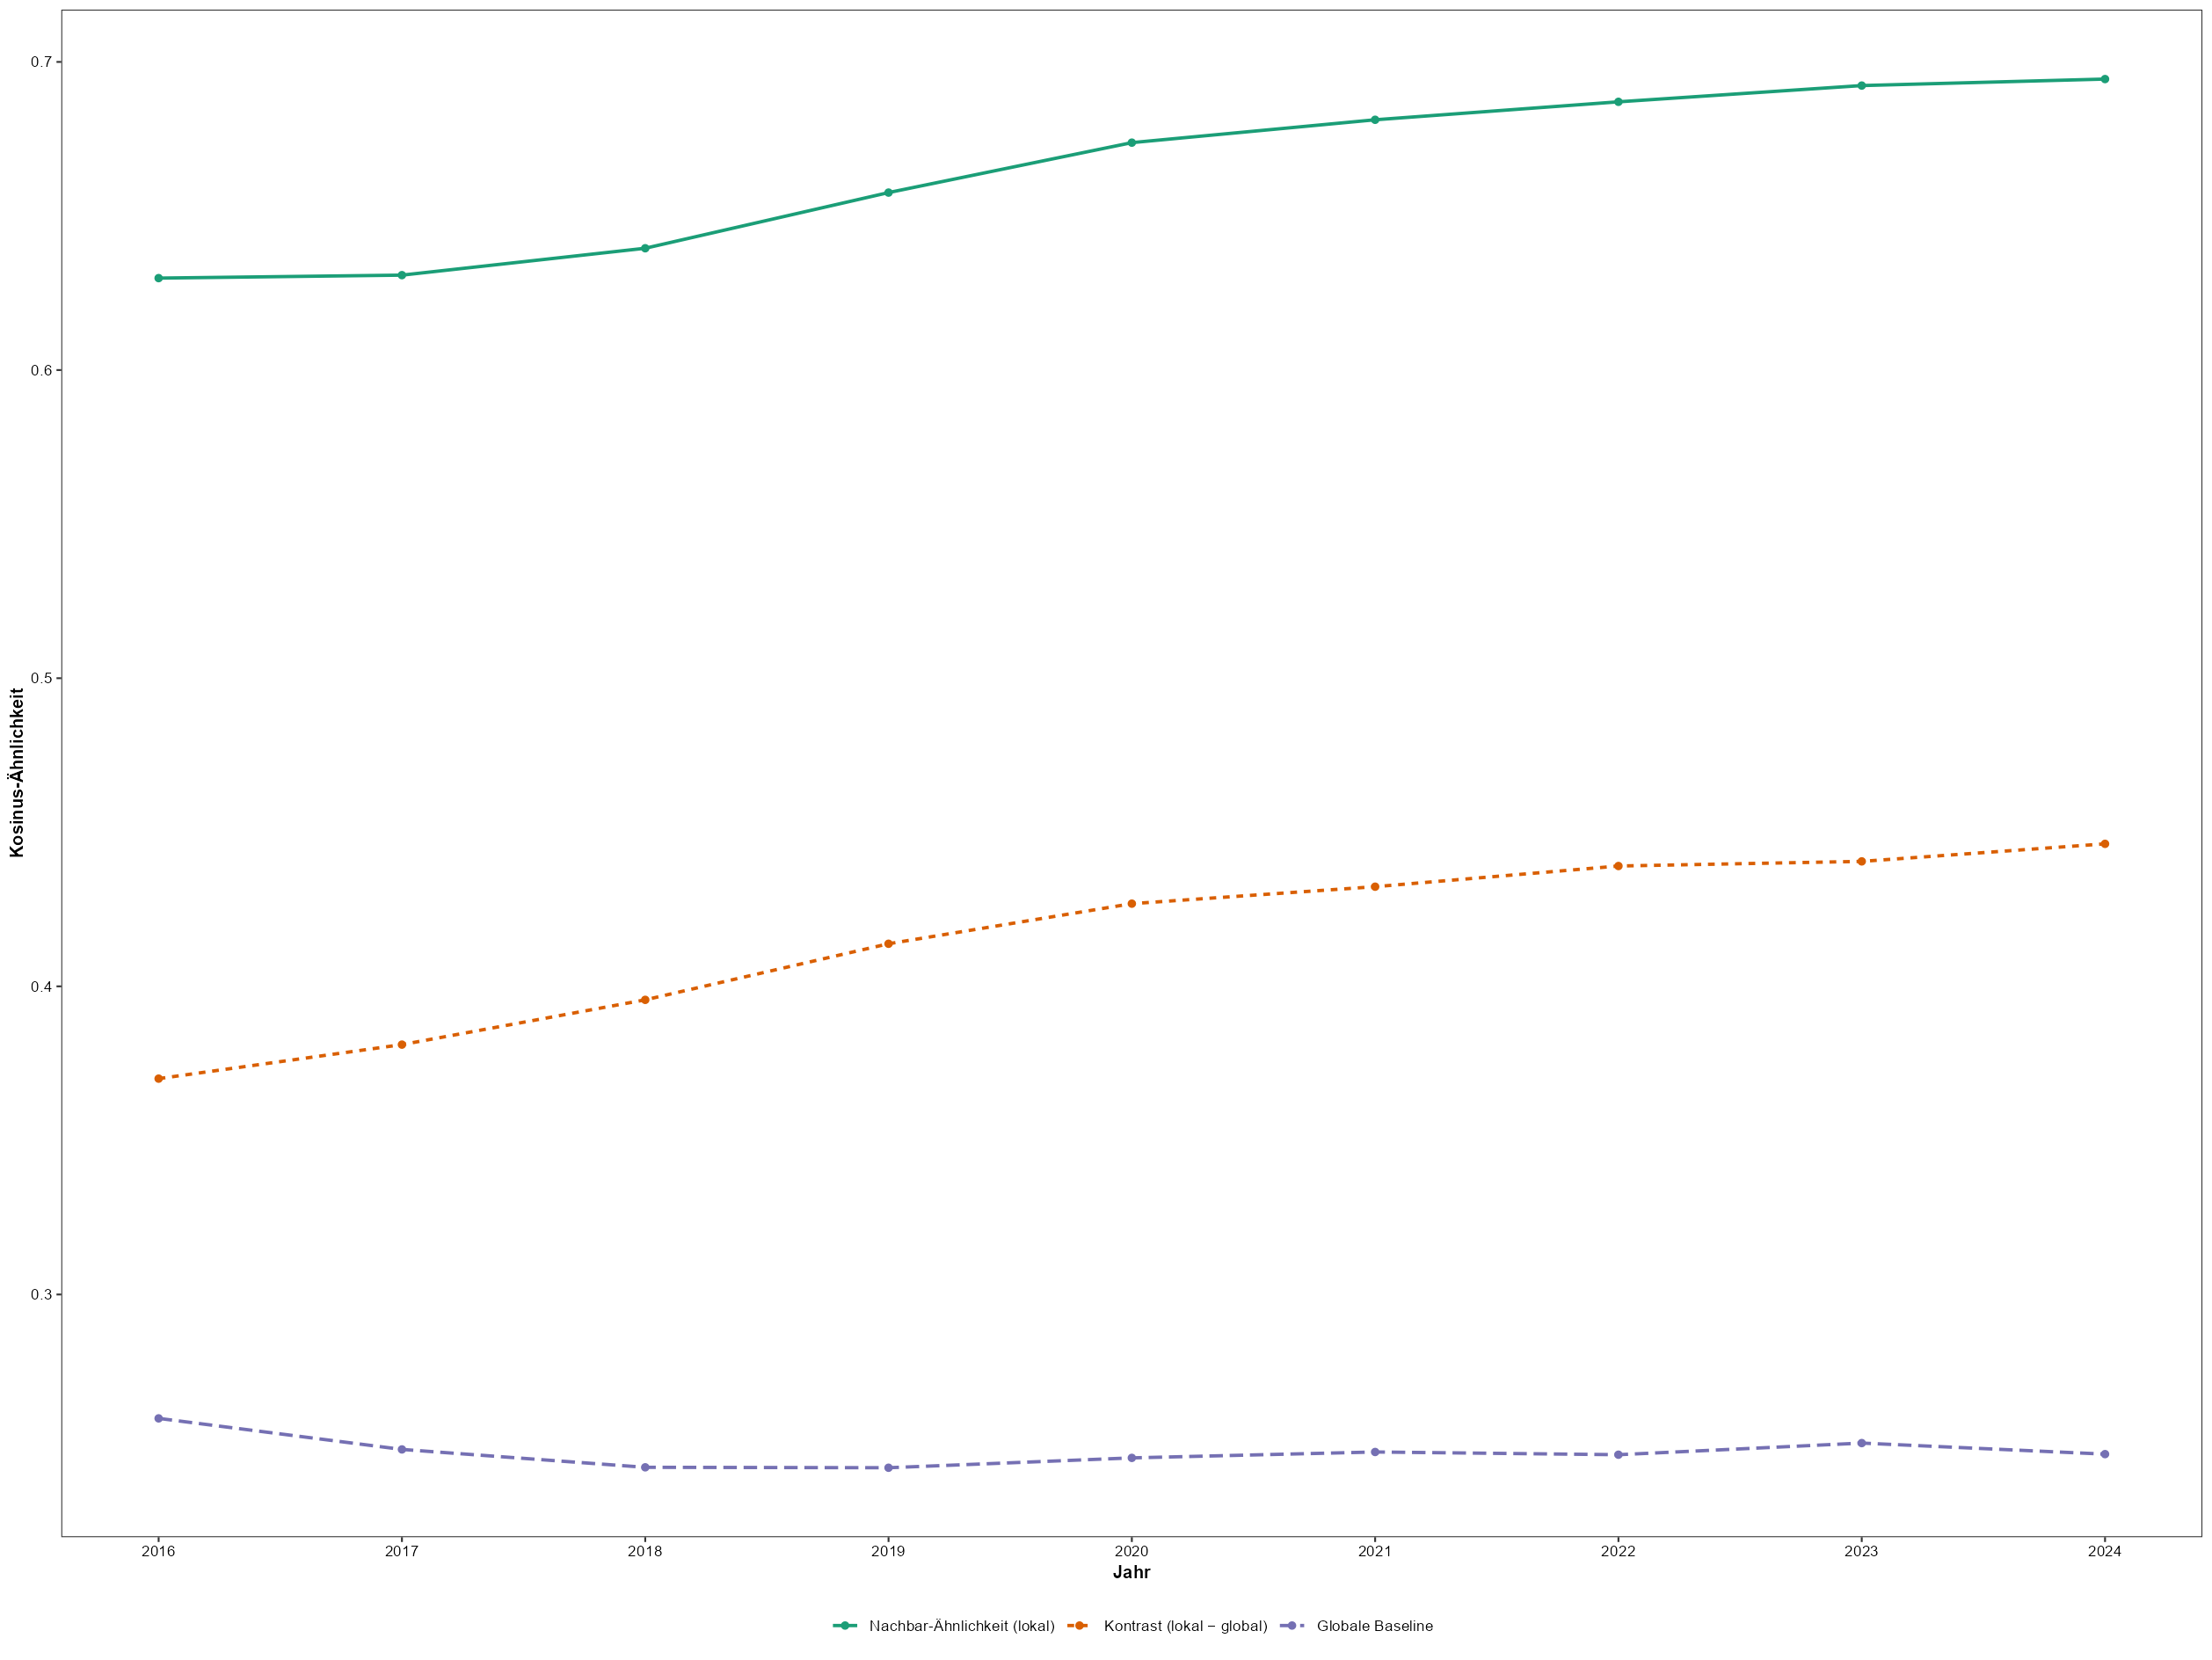

In [1]:
library(tidyverse)

ff1_geo_full <- read_csv("ff1_geo_full.csv")   # Vollwerte

# gleiches Theme wie deine Panels A-F
theme_custom <- function() {
  theme_bw() +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title   = element_text(face = "bold", size = 11, hjust = 0),
      axis.title.x = element_text(face = "bold", size = 10),
      axis.title.y = element_text(face = "bold", size = 10),
      axis.text    = element_text(color = "black"),
      legend.title = element_blank(),
      legend.position = "bottom"
    )
}

# ins Long-Format: eine Zeile pro (Jahr, Maß)
geo_long <- ff1_geo_full |>
  select(jahr, mean_nn, mean_global, kontrast) |>
  pivot_longer(-jahr, names_to = "mass", values_to = "wert") |>
  mutate(mass = recode(mass,
    mean_nn     = "Nachbar-Ähnlichkeit (lokal)",
    mean_global = "Globale Baseline",
    kontrast    = "Kontrast (lokal − global)"))

# Reihenfolge der Legende festlegen
geo_long$mass <- factor(geo_long$mass, levels = c(
  "Nachbar-Ähnlichkeit (lokal)", "Kontrast (lokal − global)", "Globale Baseline"))

p_geo <- ggplot(geo_long, aes(x = jahr, y = wert, color = mass, linetype = mass)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.6) +
  scale_x_continuous(breaks = 2016:2024) +
  scale_color_manual(values = c(
    "Nachbar-Ähnlichkeit (lokal)" = "#1b9e77",
    "Kontrast (lokal − global)"   = "#d95f02",
    "Globale Baseline"            = "#7570b3")) +
  labs(x = "Jahr", y = "Kosinus-Ähnlichkeit") +
  theme_custom()

print(p_geo)
# ggsave("ff1_geometrie.png", p_geo, width = 7, height = 4.5, dpi = 300)